# Multi-model Bayesian model averaging on CANDELS galaxies

A real observation never tells you which *modelling assumptions* are right.
Pick a single SFH family, one SSP library, one dust law, and you get a tidy
posterior — but it is conditioned on choices you cannot defend from the data
alone. This notebook does the honest thing instead: it fits the **same
galaxy** under **four genuinely different model configurations** and combines
them by **Bayesian model averaging (BMA)**, weighting each by its marginal
likelihood (evidence).

We run this for **two** CANDELS GOODS-South galaxies at $z\sim1$, and report
**per-fit timings** throughout.

| Config | SFH | SSP | Dust law | Dust emis. | Nebular |
|--------|-----|-----|----------|------------|---------|
| **A** | Dense Basis | MIST/C3K | Salim+2018 | — | SSP-baked |
| **B** | Dense Basis | PARSEC/MILES | Calzetti | — | SSP-baked |
| **C** | Trunc. skew-normal | BC03 | Kriek & Conroy | — | off |
| **D** | Double power-law | BPASS | power-law | — | off |

> **Why no dust IR emission?** At $z\sim1$ the reddest band (IRAC 8 µm) maps
> to $\sim4$ µm rest-frame — there is no far-IR photometry to constrain a
> dust-emission template, so it cannot affect the fit. It would also be a pure
> speed tax: under `WavePrecomp` the attenuated **stellar** SED is served from
> a precomputed effective-wavelength look-up table, but **additive emitters**
> (dust IR, radio, X-ray) are deliberately routed through the *exact* per-band
> filter integral (the IR template is too spiky for the LUT — see #629). That
> makes a likelihood call with dust emission more than an order of magnitude
> costlier, which dominates nested-sampling runtime (reported upstream as
> #708). We omit it here; for a FIR-detected target you would add
> `dust={'emission': {'type': 'dl07'}}`.

## Why evidence, not $\chi^2$

BMA weights are posterior model probabilities. With flat model priors,

$$
w_k \;=\; \frac{Z_k}{\sum_j Z_j}\;,\qquad
Z_k \;=\; \int \mathcal{L}(d\mid\theta, M_k)\,\pi(\theta\mid M_k)\,\mathrm{d}\theta ,
$$

where $Z_k$ is the **marginal likelihood** of model $M_k$. The evidence
automatically penalises model complexity (the Occam factor), so a more
flexible model only wins if the extra freedom is justified by the data. This
is why we fit with **nested sampling** (`"nss"`) — unlike VI/MCMC it returns a
calibrated $\log Z$ for free.

## Current public API only

Models are built with the recommended **nested-dict grammar**
(`SEDModel.build(...)`), priors with `Uniform`/`Fixed`, and we opt into the
**precompute** speed path (`approx=WavePrecomp()`) which publishes the
SSP × filter look-up table. Inference is `Fitter(model, data, noise).run("nss")`.

In [1]:
from __future__ import annotations

import time
import warnings
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")

# --- Current tengri public API ---
from tengri import (
    FIXED,
    Fitter,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    load_ssp_data,
)
from tengri.units import ab_mag_to_fnu

W0605 15:18:59.697884 2791819 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 0. Locate the repository root

Anchored on ``pyproject.toml`` so the notebook runs from any working
directory (nbconvert executes it from ``notebooks/``).

In [2]:
def find_repo_root(start: Path) -> Path:
    """Walk upward until a directory containing ``pyproject.toml`` is found."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "tengri").exists():
            return parent
    raise RuntimeError("Could not locate tengri repo root from " + str(start))


ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data"
CANDELS_DIR = ROOT / "analysis" / "hst_proposal" / "data"
FIG_DIR = ROOT / "notebooks" / "_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root : {ROOT}")
print(f"SSP grids : {DATA_DIR}")
print(f"CANDELS   : {CANDELS_DIR}")

Repo root : /Users/suchethacooray/.claude-squad/worktrees/cs-multifit-timings
SSP grids : /Users/suchethacooray/.claude-squad/worktrees/cs-multifit-timings/data
CANDELS   : /Users/suchethacooray/.claude-squad/worktrees/cs-multifit-timings/analysis/hst_proposal/data


## 1. Parse the CANDELS GOODS-South catalogue

AB magnitudes in 17 bands (HST/ACS + WFC3 + ground-based NIR + *Spitzer*
IRAC). We map a subset onto tengri filter names.

In [3]:
# Column mapping: (mag_col_index, err_col_index, tengri_filter_name).
# Catalog layout: ID, z, then 17 (mag, e_mag) pairs, then flg1, flg2.
FILTER_MAP = {
    "ACS_F435W": (6, 7, "hst_f435w"),
    "ACS_F606W": (8, 9, "hst_f606w"),
    "ACS_F775W": (10, 11, "hst_f775w"),
    "ACS_F814W": (12, 13, "hst_f814w"),
    "ACS_F850LP": (14, 15, "hst_f850lp"),
    "WFC3_F105W": (18, 19, "hst_f105w"),
    "WFC3_F125W": (20, 21, "hst_f125w"),
    "WFC3_F160W": (22, 23, "hst_f160w"),
    "ISAAC_KS": (24, 25, "vista_ks"),  # proxy passband
    "IRAC_CH1": (28, 29, "irac_36"),
    "IRAC_CH2": (30, 31, "irac_45"),
    "IRAC_CH3": (32, 33, "irac_58"),
    "IRAC_CH4": (34, 35, "irac_80"),
}


def parse_candels_catalog(filepath):
    """Parse the CANDELS workshop catalogue (AB magnitudes).

    Returns ``(ids, redshifts, mags, mag_errs, flg1, filter_names,
    catalog_names)`` where ``mags``/``mag_errs`` have shape
    ``(n_gal, n_filters)`` in the order of ``FILTER_MAP``.
    """
    raw = np.loadtxt(filepath, dtype=str)
    ids = raw[:, 0].astype(int)
    redshifts = raw[:, 1].astype(float)
    flg1 = raw[:, -2].astype(int)

    catalog_names = list(FILTER_MAP.keys())
    filter_names = [v[2] for v in FILTER_MAP.values()]

    mags = np.full((len(ids), len(FILTER_MAP)), np.nan)
    mag_errs = np.full((len(ids), len(FILTER_MAP)), np.nan)
    for i, (_n, (mag_col, err_col, _)) in enumerate(FILTER_MAP.items()):
        mags[:, i] = raw[:, mag_col].astype(float)
        mag_errs[:, i] = raw[:, err_col].astype(float)
    return ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names


ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names = parse_candels_catalog(
    CANDELS_DIR / "CANDELS_GDSS_workshop_z1.dat"
)

# Bad-photometry flags
flagged_ids = set()
flags_file = CANDELS_DIR / "flags_z1.dat"
if flags_file.exists():
    for line in flags_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            parts = line.split()
            if len(parts) >= 2:
                flagged_ids.add(int(parts[0]))

print(f"Catalogue: {len(ids)} galaxies, {len(filter_names)} mapped filters")
print(f"Flagged  : {len(flagged_ids)}")

Catalogue: 371 galaxies, 13 mapped filters
Flagged  : 32


## 2. AB mag → $f_\nu$, and galaxy selection

We use the public `tengri.units.ab_mag_to_fnu` for the flux conversion and
pick the two highest-S/N star-forming galaxies at $z\sim1$ with $\ge10$
detected bands and clean flags.

In [4]:
NON_DETECT = 90.0  # mag > 90 ⇒ non-detection in this catalogue


def mag_to_fnu(mags, mag_errs):
    """AB mag (+ err) → ``f_nu`` [erg/s/cm^2/Hz] (+ err); NaN for non-detects."""
    detected = (mags < NON_DETECT) & (mag_errs > 0)
    fnu = np.full_like(mags, np.nan, dtype=np.float64)
    sig = np.full_like(mags, np.nan, dtype=np.float64)
    fnu[detected] = np.asarray(ab_mag_to_fnu(jnp.asarray(mags[detected])))
    sig[detected] = fnu[detected] * mag_errs[detected] * np.log(10) / 2.5
    return fnu, sig, detected


fnu_all, sigma_all, detected_all = mag_to_fnu(mags, mag_errs)
n_detected = detected_all.sum(axis=1)

z_mask = (redshifts > 0.95) & (redshifts < 1.15)
flag_mask = np.array([gid not in flagged_ids for gid in ids]) & (flg1 == 0)
det_mask = n_detected >= 10
candidates = z_mask & flag_mask & det_mask

median_snr = np.zeros(len(ids))
for i in range(len(ids)):
    if detected_all[i].any():
        median_snr[i] = np.median(fnu_all[i, detected_all[i]] / sigma_all[i, detected_all[i]])

cand_idx = np.where(candidates)[0]
cand_idx = cand_idx[np.argsort(-median_snr[cand_idx])]

# Two galaxies chosen to show the range of model-averaging behaviour:
#   CANDELS 4171  — a clean main-sequence case where several configs contribute;
#   CANDELS 17418 — a second z~1 star-former.
# (Both are among the high-S/N, well-fit candidates below.)
GAL_IDS = [4171, 17418]
SELECTED_IDX = [int(np.where(ids == g)[0][0]) for g in GAL_IDS]

print("Top candidates (z~1, ≥10 bands, clean flags):")
print(f"{'ID':>8s} {'z':>6s} {'N_det':>5s} {'med S/N':>8s}  pick")
for idx in cand_idx[:8]:
    mark = "  <--" if ids[idx] in GAL_IDS else ""
    print(f"{ids[idx]:8d} {redshifts[idx]:6.3f} {n_detected[idx]:5d} {median_snr[idx]:8.1f}{mark}")


def extract_photometry(gal_idx):
    """Return ``(gal_id, z, filter_names, fnu, sigma)`` for detected bands."""
    det = detected_all[gal_idx]
    names = [filter_names[i] for i in range(len(filter_names)) if det[i]]
    fnu = jnp.asarray(fnu_all[gal_idx, det])
    sig = jnp.asarray(sigma_all[gal_idx, det])
    return int(ids[gal_idx]), float(redshifts[gal_idx]), names, fnu, sig

Top candidates (z~1, ≥10 bands, clean flags):
      ID      z N_det  med S/N  pick
   17418  1.096    12    542.9  <--
   24497  1.031    11    542.9
   16049  1.047    13    271.4
   18160  1.095    13    271.4
   13097  1.097    13    271.4
   16435  1.094    13    217.1
   16455  1.087    13    217.1
   15775  1.097    13    217.1


## 3. Load the four SSP libraries

Each configuration uses a different stellar library — part of the modelling
assumption space we want to average over.

In [5]:
t0 = time.time()
SSP = {
    "mist": load_ssp_data(str(DATA_DIR / "ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")),
    "padova": load_ssp_data(
        str(DATA_DIR / "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
    ),
    "bc03": load_ssp_data(str(DATA_DIR / "bc03_pdva_stelib_chabrier.h5")),
    "bpass": load_ssp_data(str(DATA_DIR / "bpss_stars_c3k_a_chabrier.h5")),
}
print(f"4 SSP libraries loaded in {time.time() - t0:.1f}s")

W0605 15:19:01.098700 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.103273 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.112079 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.117069 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.141135 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


4 SSP libraries loaded in 0.4s


## 4. The four model configurations (`SEDModel.build`)

Each config is built with the nested-dict grammar. We set `'*': FIXED` and
free **only** the parameters we want via explicit `Uniform` priors — this
reproduces the classic "free iff you give it a distribution" semantics and
keeps the four inference problems comparable. `approx=WavePrecomp()` turns on
the precompute speed path.

In [6]:
# Shared priors
DB_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    "log_sfr_inst": Uniform(-2.0, 3.0),
    "tx_frac_0": Uniform(0.05, 0.95),
    "tx_frac_1": Uniform(0.05, 0.95),
    "tx_frac_2": Uniform(0.05, 0.95),
}
DUST = {"tau_bc": Uniform(0.0, 3.0), "tau_diff": Uniform(0.0, 2.0)}

# Display metadata (colours/labels match the published proposal figure)
CONFIG_ORDER = ["A", "B", "C", "D"]
SSP_FOR = {"A": "mist", "B": "padova", "C": "bc03", "D": "bpass"}
COLORS = {"A": "#1b9e77", "B": "#d95f02", "C": "#7570b3", "D": "#e7298a"}
BMA_COLOR = "0.1"
LABELS = {
    "A": "Dense Basis / MIST / Salim / neb.",
    "B": "Dense Basis / Padova / Calzetti",
    "C": r"Trunc. Skew-Normal / BC03 / K\&C",
    "D": "Double Power Law / BPASS / power-law",
}


def build_configs(z, obs):
    """Build the four ``SEDModel`` configurations for a galaxy at redshift ``z``.

    Returns ``{config_letter: SEDModel}``. Each model opts into the precompute
    (``WavePrecomp``) speed path.
    """
    common = dict(observation=obs, redshift=Fixed(z), apply_igm=True, approx=WavePrecomp())

    model_a = SEDModel.build(
        ssp_data=SSP["mist"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "salim_sbl18", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_b = SEDModel.build(
        ssp_data=SSP["padova"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_c = SEDModel.build(
        ssp_data=SSP["bc03"],
        sfh={
            "type": "tsnorm",
            "*": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            "log_total_mass": Uniform(8.0, 12.0),
            "peak_lbt_gyr": Uniform(0.5, 12.0),
            "width_gyr": Uniform(0.2, 5.0),
            "skew": Uniform(-1.0, 1.0),
            "trunc": Uniform(1.0, 10.0),
        },
        dust={"type": "two_component", "law_bc": "kriek_conroy", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    model_d = SEDModel.build(
        ssp_data=SSP["bpass"],
        sfh={
            "type": "dpl",
            "*": FIXED,
            "met_logzsol": Fixed(-0.3),
            "alpha": Uniform(0.5, 5.0),
            "beta": Uniform(0.3, 3.0),
            "tau_gyr": Uniform(0.5, 13.0),
            "log_total_mass": Uniform(8.0, 12.0),
        },
        dust={"type": "two_component", "law_bc": "power_law", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    return {"A": model_a, "B": model_b, "C": model_c, "D": model_d}

## 5. Fit every (galaxy × config) with nested sampling

Nested slice sampling (`"nss"`), `n_live=500`, using the catalogue flux
uncertainties directly. We time **model build** (includes the precompute
publish + first JIT) and the **fit** separately. With the real (small) errors
each model is tightly constrained, so the per-model posteriors separate
cleanly — the evidence then decides how to weight them.

In [7]:
N_LIVE = 500
N_POST = 1000

galaxies = {}  # gal_id -> dict(z, names, fnu, sigma, models, posteriors, timings)

for gal_idx in SELECTED_IDX:
    gal_id, z, names, fnu, sigma = extract_photometry(gal_idx)
    print(
        f"\n{'#' * 64}\n# Galaxy CANDELS {gal_id}  (z = {z:.3f}, {len(names)} bands)\n{'#' * 64}"
    )

    obs = Observation(photometry=Photometry.from_names(names))

    t_build = time.time()
    models = build_configs(z, obs)
    build_s = time.time() - t_build
    print(f"  built 4 models in {build_s:.1f}s")

    posteriors, fit_timings = {}, {}
    for cfg in CONFIG_ORDER:
        model = models[cfg]
        n_free = len(model.spec.free_params)
        key = jax.random.PRNGKey(abs(hash((gal_id, cfg))) % (2**31))
        t_fit = time.time()
        post = Fitter(model, fnu, sigma).run(
            "nss", key=key, n_live=N_LIVE, n_posterior_samples=N_POST, verbose=False
        )
        dt = time.time() - t_fit
        posteriors[cfg] = post
        fit_timings[cfg] = dt
        print(f"  [{cfg}] D={n_free:2d}  fit {dt:6.1f}s  logZ = {post.log_evidence:8.1f}")

    galaxies[gal_id] = dict(
        z=z,
        names=names,
        fnu=np.asarray(fnu),
        sigma=np.asarray(sigma),
        models=models,
        posteriors=posteriors,
        build_s=build_s,
        fit_timings=fit_timings,
    )

print("\nAll fits complete.")


################################################################
# Galaxy CANDELS 4171  (z = 1.032, 11 bands)
################################################################


W0605 15:19:01.424798 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.455912 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 15:19:01.799001 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.802710 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.873240 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.947401 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.953002 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.956789 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.961447 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:01.965124 2791628 pjrt_executable.cc:638] Assume v

W0605 15:19:02.034902 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:02.107620 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:19:02.187010 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  built 4 models in 0.4s


...

W0605 15:25:08.833880 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:08.994542 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 15:25:34.766803 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 15:25:35.258617 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  [D] D= 6  fit   29.6s  logZ = -14632.6

All fits complete.


W0605 15:25:35.575721 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:35.578707 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:35.581542 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:35.608851 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:35.657999 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:35.661611 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:35.674948 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 6. Timing summary

In [8]:
print(
    f"{'Galaxy':>14s} {'build':>7s} "
    + " ".join(f"{'fit ' + c:>9s}" for c in CONFIG_ORDER)
    + f" {'total':>8s}"
)
for gal_id, g in galaxies.items():
    fits = " ".join(f"{g['fit_timings'][c]:9.1f}" for c in CONFIG_ORDER)
    total = g["build_s"] + sum(g["fit_timings"].values())
    print(f"CANDELS {gal_id:>6d} {g['build_s']:7.1f} {fits} {total:8.1f}")
print("(seconds; build includes precompute publish + first JIT compile)")

        Galaxy   build     fit A     fit B     fit C     fit D    total
CANDELS   4171     0.4      63.0      45.4      41.6      15.2    165.6
CANDELS  17418     0.4      62.2      53.6      82.2      29.6    228.0
(seconds; build includes precompute publish + first JIT compile)


## 7. Posterior predictions + Bayesian model averaging

For each fit we draw posterior SEDs, SFHs, and derived $(M_\star,
\mathrm{SFR})$. BMA weights come from the evidences; the BMA predictive is an
evidence-weighted pool of the per-config draws.

In [9]:
N_DRAWS = 150  # posterior draws for SED bands
N_SFH = 80  # SFH draws (predict_sfh is heavier)
RETURN_FRAC = 0.6  # surviving / formed mass (Chabrier; Madau & Dickinson 2014)
WAVE_SPEC = np.logspace(np.log10(3000), np.log10(1e5), 300)  # observed-frame Å
rng = np.random.default_rng(0)


# Effective wavelengths + half-widths [Å] of the catalogue bands, computed from
# the *actual* filter transmission curves (single source of truth — not
# hardcoded): mean effective wavelength and rectangular-equivalent half-width
# W/2 = (1/2) ∫T dλ / max(T), used for the photometry x error bars.
def _filter_eff_and_halfwidth(names):
    phot = Photometry.from_names(names)
    eff, half = {}, {}
    for i, nm in enumerate(phot.names):
        w = np.asarray(phot.filter_waves[i], dtype=float)
        t = np.asarray(phot.filter_trans[i], dtype=float)
        good = t > 0
        w, t = w[good], t[good]
        eff[nm] = float(np.trapz(w * t, w) / np.trapz(t, w))
        half[nm] = float(0.5 * np.trapz(t, w) / t.max())
    return eff, half


WAVE_EFF, FILTER_HALFWIDTH = _filter_eff_and_halfwidth(filter_names)


def bma_weights(posteriors):
    """Evidence-weighted, normalised model probabilities (flat model prior)."""
    logz = np.array([posteriors[c].log_evidence for c in CONFIG_ORDER])
    w = np.exp(logz - logz.max())
    return w / w.sum()


def bin_to_grid(wave, y, grid):
    """Downsample ``y(wave)`` onto ``grid`` by mean within log-spaced bins.

    A binned mean (rather than point interpolation) keeps narrow nebular
    emission lines at the *resolution of the plot grid* — so they appear as
    modest bumps rather than aliased full-height spikes, matching a coarsely
    sampled spectrum.
    """
    edges = np.empty(len(grid) + 1)
    edges[1:-1] = np.sqrt(grid[1:] * grid[:-1])
    edges[0], edges[-1] = grid[0], grid[-1]
    tot, _ = np.histogram(wave, bins=edges, weights=y)
    cnt, _ = np.histogram(wave, bins=edges)
    out = np.divide(tot, cnt, out=np.full_like(tot, np.nan), where=cnt > 0)
    empty = ~np.isfinite(out)
    if empty.any():  # fill any empty bins by interpolation from filled ones
        out[empty] = np.interp(grid[empty], grid[~empty], out[~empty])
    return out


def vmap_chunked(fn, batch, n, chunk=16):
    """``jax.jit(jax.vmap(fn))`` over an ``n``-draw batch in memory-bounded chunks.

    A bare ``vmap`` only batches eager ops (slower than the loop); ``jax.jit``
    compiles the batched forward into one kernel (~7x). vmapping all draws at
    once OOMs, so we chunk (peak memory ~ ``chunk``; the final partial chunk
    triggers one extra cheap compile). Results concatenate along the draw axis.
    """
    vfn = jax.jit(jax.vmap(fn))
    parts = [vfn({k: v[s : s + chunk] for k, v in batch.items()}) for s in range(0, n, chunk)]
    return jax.tree_util.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *parts)


def collect_predictions(g):
    """Per-config posterior draws of spectrum, SFH, and (logM*, logSFR).

    The continuous SED comes from ``predict_obs_sed`` (observed-frame rest L_nu
    on each SSP's native grid). We rescale L_nu to observed ``f_nu`` with the
    distance factor anchored to ``predict_photometry`` (a pure constant,
    4*pi*d_L^2 / (1+z)), then bin every config onto the common ``WAVE_SPEC``
    grid so the four can be pooled for the BMA predictive.

    SED and derived (M*, SFR) draws use chunked ``jax.jit(jax.vmap)`` (~7x vs a
    Python loop). The forward path lazily builds its precompute LUT *inside* the
    traced call and would leak a tracer under JIT (perf issue #715), so we
    **eager-warm** each model once (a plain call per method) to make the LUT
    concrete before jitting. ``predict_sfh`` is not jittable
    (``ConcretizationTypeError``), so the SFH curve stays an eager loop.
    """
    weff = np.array([WAVE_EFF[n] for n in g["names"]])
    spec, sfh, props = {}, {}, {}
    for cfg in CONFIG_ORDER:
        model = g["models"][cfg]
        samples = g["posteriors"][cfg].samples
        n_avail = next(iter(samples.values())).shape[0]
        n_use = min(N_DRAWS, n_avail)
        batch = {k: v[:n_use] for k, v in samples.items()}

        # Eager-warm the forward caches concretely (so the LUT is not built under
        # the JIT trace -> no tracer leak), and get the L_nu->f_nu scale factor.
        s0 = {k: v[0] for k, v in samples.items()}
        wave_nat, lnu0 = (np.asarray(a) for a in model.predict_obs_sed(s0))
        phot0 = np.asarray(model.predict_photometry(s0))
        model.predict_sfh_quantities(s0)  # warm
        flux_factor = np.median(phot0 / np.interp(weff, wave_nat, lnu0))

        # SED + derived quantities: chunked jit(vmap) over the draw batch.
        lnu_b = np.asarray(vmap_chunked(model.predict_obs_sed, batch, n_use)[1])
        spec[cfg] = np.array(
            [bin_to_grid(wave_nat, lnu_b[i] * flux_factor, WAVE_SPEC) for i in range(n_use)]
        )
        q = vmap_chunked(model.predict_sfh_quantities, batch, n_use)
        props[cfg] = {
            "log_mass": np.log10(np.maximum(np.asarray(q.stellar_mass) * RETURN_FRAC, 1e-30)),
            "log_sfr": np.log10(np.maximum(np.asarray(q.sfr_100myr), 1e-30)),
        }

        # SFH curve: eager loop (predict_sfh is not jittable).
        sfr_arr, t_gyr = [], None
        for i in range(min(n_use, N_SFH)):
            out = model.predict_sfh({k: v[i] for k, v in samples.items()})
            t_gyr = np.asarray(out["t_gyr"]) if t_gyr is None else t_gyr
            sfr_arr.append(np.asarray(out["sfr_full"]))
        sfh[cfg] = {"t_gyr": t_gyr, "sfr": np.array(sfr_arr)}
    return spec, sfh, props


for gal_id, g in galaxies.items():
    g["weights"] = bma_weights(g["posteriors"])
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    wstr = "  ".join(f"{c}={w:.2f}" for c, w in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id}  BMA weights:  {wstr}")

W0605 15:25:36.287029 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.290785 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.345998 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.359045 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.362933 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.405894 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.409640 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.413049 2791628 pjrt_executable.cc:638] Assume v

W0605 15:25:36.516297 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.521300 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:36.617692 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 15:25:37.140667 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:37.165026 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:37.182003 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 15:25:37.423068 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:37.503998 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:37.510614 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:37.525351 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:25:37.570254 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 15:25:37.696026 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 15:26:02.986897 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:26:03.144256 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 15:26:03.432191 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:26:03.592257 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 15:26:03.779400 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 15:26:03.916936 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


CANDELS 17418  BMA weights:  A=1.00  B=0.00  C=0.00  D=0.00


W0605 15:26:04.039602 2791628 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 8. Figures — one galaxy per figure

Each galaxy gets its **own** three-panel figure (publication style via
`scienceplots`): **(a)** observed photometry (red) + per-config posterior SEDs
+ the BMA predictive (black); **(b)** inferred SFHs with the model legend;
**(c)** the $M_\star$–SFR posterior as filled 68/95% credible contours, with
the evidence-weighted BMA in black. The BMA band/contour is broader than any
single model — it folds in the *between-model* uncertainty the individual fits
cannot see.

In [10]:
import scienceplots

plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "figure.dpi": 220,
        "savefig.dpi": 400,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.3,
        "ytick.minor.width": 0.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

POINT_COLOR = "#e8000b"  # red photometry markers (matches proposal figure)
# FILTER_HALFWIDTH is computed from the real transmission curves above (the x
# error bars on the photometry are the filters' rectangular-equivalent widths).


def pool(per_cfg, weights, total):
    """Evidence-weighted pool of per-config draw arrays (axis 0 = draws)."""
    out = []
    for cfg, w in zip(CONFIG_ORDER, weights):
        arr = per_cfg[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(arr), size=min(n, len(arr)), replace=True)
        out.append(arr[idx])
    return np.concatenate(out, axis=0)


def pool_pairs(per_cfg_x, per_cfg_y, weights, total):
    """Evidence-weighted pool of *paired* (x, y) draws — one index set per config.

    Keeps the (M*, SFR) correlation intact; pooling x and y with independent
    ``rng.choice`` calls would decorrelate them and misplace the BMA contour.
    """
    xs, ys = [], []
    for cfg, w in zip(CONFIG_ORDER, weights):
        x, y = per_cfg_x[cfg], per_cfg_y[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(x), size=min(n, len(x)), replace=True)
        xs.append(x[idx])
        ys.append(y[idx])
    return np.concatenate(xs), np.concatenate(ys)


def filled_kde(ax, x, y, color, *, zorder=2, bma=False):
    """Filled 68/95% credible contours of a 2-D KDE (point if degenerate)."""
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    if len(x) < 5 or x.std() < 1e-6 or y.std() < 1e-6:
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except np.linalg.LinAlgError:
        return
    xg = np.linspace(x.mean() - 4 * x.std(), x.mean() + 4 * x.std(), 120)
    yg = np.linspace(y.mean() - 4 * y.std(), y.mean() + 4 * y.std(), 120)
    XG, YG = np.meshgrid(xg, yg)
    ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
    zs = np.sort(ZG.ravel())[::-1]
    zc = np.cumsum(zs) / zs.sum()
    l68, l95 = zs[np.searchsorted(zc, 0.68)], zs[np.searchsorted(zc, 0.95)]
    zmax = ZG.max()
    if not (l95 < l68 < zmax):
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    a95, a68 = (0.45, 0.85) if bma else (0.30, 0.65)
    ax.contourf(
        XG, YG, ZG, levels=[l95, l68, zmax], colors=[color, color], alpha=a95, zorder=zorder
    )
    ax.contourf(XG, YG, ZG, levels=[l68, zmax], colors=[color], alpha=a68 - a95, zorder=zorder)
    ax.contour(
        XG, YG, ZG, levels=[l95], colors="k" if bma else [color],
        linewidths=0.7 if bma else 0.4, alpha=0.9, zorder=zorder + 0.1,
    )  # fmt: skip


def plot_galaxy(gal_id, *, presentation=False):
    """Render the three-panel multi-model + BMA figure for one galaxy.

    ``presentation=True`` produces a larger, slide-ready version (bigger fonts
    and panels, thicker lines, a BMA-weight annotation) saved as ``*_pres.png``;
    the default is the compact paper figure (``*.png``).
    """
    g = galaxies[gal_id]
    w = g["weights"]
    # Sizing / styling: (paper, presentation).
    P = presentation
    figsize = (13.0, 3.7) if P else (6.5, 1.65)
    margins = dict(bottom=0.17, top=0.84) if P else dict(bottom=0.18, top=0.88)
    fs_pan, fs_lab, fs_tick = (16, 15, 12) if P else (8, 8, 7)
    fs_leg, fs_box = (12, 13) if P else (6.5, 6)
    lw_cfg, lw_bma, ms, ew = (1.8, 3.2, 7.5, 1.4) if P else (0.8, 1.5, 3.5, 0.7)
    leg_y = 1.14 if P else 1.12

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1.15, 1.0, 1.0],
                  wspace=0.42 if P else 0.38, left=0.07, right=0.985, **margins)  # fmt: skip

    def panel_label(ax, s):
        ax.text(0.04, 0.93, s, transform=ax.transAxes, fontsize=fs_pan, va="top")

    # ---- (a) SED ----
    ax = fig.add_subplot(gs[0])
    for cfg in CONFIG_ORDER:
        d = g["spec"][cfg]
        ax.fill_between(WAVE_SPEC, np.percentile(d, 16, 0), np.percentile(d, 84, 0),
                        color=COLORS[cfg], alpha=0.12, lw=0)  # fmt: skip
        ax.plot(WAVE_SPEC, np.median(d, 0), "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.85)
    bma = pool(g["spec"], w, 300)
    ax.fill_between(WAVE_SPEC, np.percentile(bma, 16, 0), np.percentile(bma, 84, 0),
                    color=BMA_COLOR, alpha=0.10, lw=0)  # fmt: skip
    ax.plot(WAVE_SPEC, np.median(bma, 0), "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95, zorder=5)
    wobs = np.array([WAVE_EFF[n] for n in g["names"]])
    xerr = np.array([FILTER_HALFWIDTH[n] for n in g["names"]])  # real filter half-widths
    ax.errorbar(wobs, g["fnu"], yerr=g["sigma"], xerr=xerr, fmt="o", ms=ms,
                color=POINT_COLOR, ecolor="0.3", elinewidth=ew, capsize=0,
                markeredgewidth=0, zorder=10)  # fmt: skip
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(3200, 1e5)
    fnu_pos = g["fnu"][g["fnu"] > 0]
    ax.set_ylim(0.3 * fnu_pos.min(), 4 * fnu_pos.max())  # frame on the data
    ax.set_xlabel(r"$\lambda_\mathrm{obs}$ [$\AA$]", fontsize=fs_lab)
    ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(a)}$")
    ax.text(
        0.96, 0.08, f"CANDELS {gal_id}\n$z = {g['z']:.3f}$", transform=ax.transAxes,
        fontsize=fs_box, ha="right", va="bottom",
        bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "0.7", "lw": 0.5, "alpha": 0.9},
    )  # fmt: skip

    # ---- (b) SFH ----
    ax = fig.add_subplot(gs[1])
    maxes = []
    for cfg in CONFIG_ORDER:
        t, sfr = g["sfh"][cfg]["t_gyr"], g["sfh"][cfg]["sfr"]
        med = np.median(sfr, 0)
        ax.fill_between(t, np.percentile(sfr, 16, 0), np.percentile(sfr, 84, 0),
                        color=COLORS[cfg], alpha=0.15, lw=0)  # fmt: skip
        ax.plot(t, med, "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.9)
        maxes.append(np.max(med[(t >= 0.15) & (t < 5)]))  # ignore the t->0 instantaneous spike
    t_common = g["sfh"]["A"]["t_gyr"]
    bma_sfr = pool({c: g["sfh"][c]["sfr"] for c in CONFIG_ORDER}, w, 200)
    bma_med = np.median(bma_sfr, 0)
    ax.fill_between(t_common, np.percentile(bma_sfr, 16, 0), np.percentile(bma_sfr, 84, 0),
                    color=BMA_COLOR, alpha=0.15, lw=0)  # fmt: skip
    ax.plot(t_common, bma_med, "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95)
    maxes.append(np.max(bma_med[(t_common >= 0.15) & (t_common < 5)]))
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1.25 * max(maxes))  # robust: fills the panel, ignores t->0 spike
    ax.set_xlabel("Lookback time [Gyr]", fontsize=fs_lab)
    ax.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(b)}$")

    # ---- (c) M*-SFR ----
    ax = fig.add_subplot(gs[2])
    for cfg in CONFIG_ORDER:
        filled_kde(ax, g["props"][cfg]["log_mass"], g["props"][cfg]["log_sfr"],
                   COLORS[cfg], zorder=3)  # fmt: skip
    bm, bs = pool_pairs(
        {c: g["props"][c]["log_mass"] for c in CONFIG_ORDER},
        {c: g["props"][c]["log_sfr"] for c in CONFIG_ORDER},
        w, 2000,
    )  # fmt: skip
    filled_kde(ax, bm, bs, BMA_COLOR, zorder=6, bma=True)
    ax.margins(0.18)  # padding so the small clusters aren't cramped
    ax.set_xlabel(r"$\log\,(M_\star\,/\,M_\odot)$", fontsize=fs_lab)
    ax.set_ylabel(r"$\log\,(\mathrm{SFR}_{100}\,/\,M_\odot\,\mathrm{yr}^{-1})$", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(c)}$")
    wstr = "   ".join(f"{c} {x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    ax.text(0.5, 0.97, f"BMA weights:  {wstr}", transform=ax.transAxes,
            ha="center", va="top", fontsize=fs_box)  # fmt: skip

    # Shared legend across the top, two rows (3 + 2 entries).
    handles = [Line2D([0], [0], color=COLORS[c], lw=2.2 if P else 1.6, label=LABELS[c])
               for c in CONFIG_ORDER]  # fmt: skip
    handles.append(
        Line2D([0], [0], color=BMA_COLOR, lw=3.0 if P else 2.5, label="Bayesian Model Avg.")
    )
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, leg_y), ncol=3,
               fontsize=fs_leg, frameon=True, edgecolor="0.7", framealpha=0.95,
               handlelength=1.6, columnspacing=1.4, handletextpad=0.4, labelspacing=0.3)  # fmt: skip

    suffix = "_pres" if P else ""
    fig.savefig(FIG_DIR / f"multimodel_bma_candels_{gal_id}{suffix}.png",
                dpi=200 if P else 400, bbox_inches="tight")  # fmt: skip
    plt.show()
    wstr_print = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    print(f"CANDELS {gal_id}: BMA weights  {wstr_print}")


def show_timings(gal_id):
    """Per-galaxy timing + evidence breakdown (build, per-config fit, log Z)."""
    g = galaxies[gal_id]
    print(f"CANDELS {gal_id}  (z = {g['z']:.3f}, {len(g['names'])} bands)")
    print(f"  build (4 models, incl. precompute publish + first compile): {g['build_s']:5.1f} s")
    print(f"  {'configuration':<34s} {'D':>2s} {'fit [s]':>8s} {'log Z':>9s}")
    for cfg in CONFIG_ORDER:
        n_free = len(g["models"][cfg].spec.free_params)
        print(
            f"  {LABELS[cfg]:<34s} {n_free:>2d} "
            f"{g['fit_timings'][cfg]:>8.1f} {g['posteriors'][cfg].log_evidence:>9.1f}"
        )
    print(f"  {'total fit time':<34s} {'':>2s} {sum(g['fit_timings'].values()):>8.1f}")

### CANDELS 4171

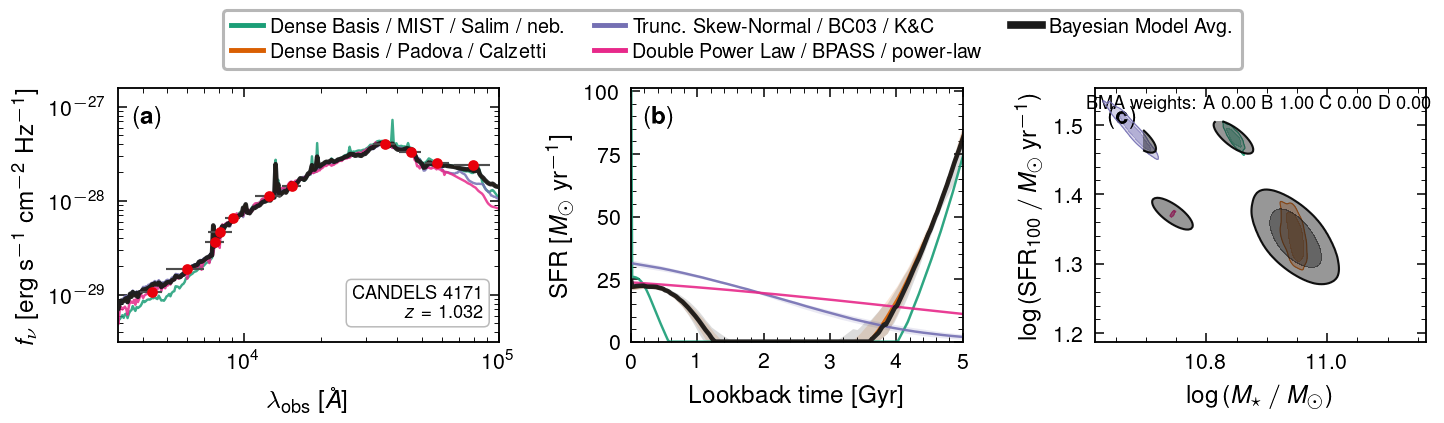

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [11]:
plot_galaxy(4171)

In [12]:
show_timings(4171)

CANDELS 4171  (z = 1.032, 11 bands)
  build (4 models, incl. precompute publish + first compile):   0.4 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     63.0    -253.2
  Dense Basis / Padova / Calzetti     8     45.4    -148.4
  Trunc. Skew-Normal / BC03 / K\&C    8     41.6    -233.4
  Double Power Law / BPASS / power-law  6     15.2    -460.5
  total fit time                           165.2


### CANDELS 17418

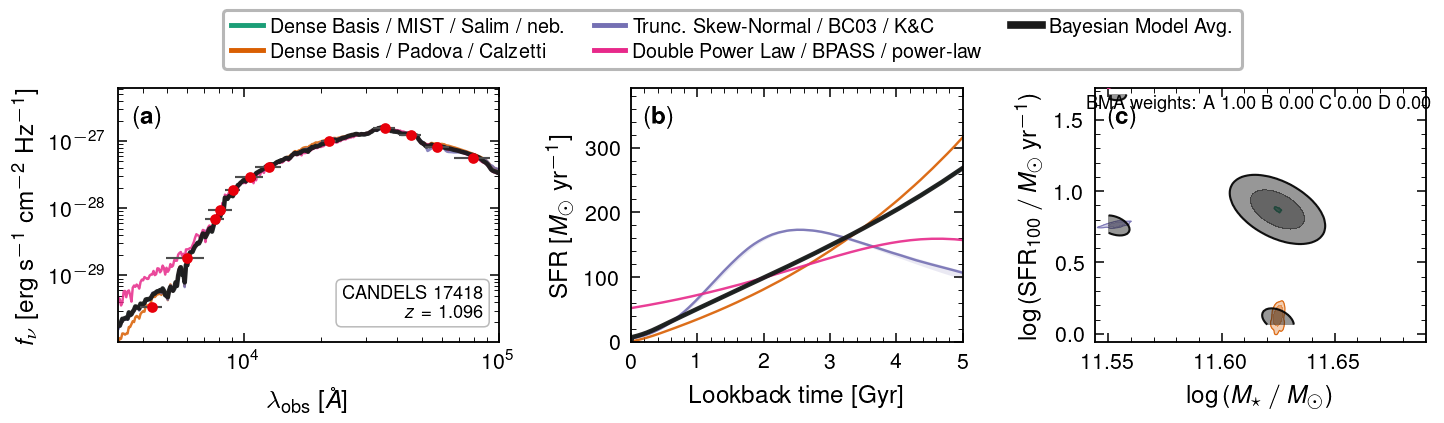

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [13]:
plot_galaxy(17418)

In [14]:
show_timings(17418)

CANDELS 17418  (z = 1.096, 12 bands)
  build (4 models, incl. precompute publish + first compile):   0.4 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     62.2   -2280.9
  Dense Basis / Padova / Calzetti     8     53.6   -2944.1
  Trunc. Skew-Normal / BC03 / K\&C    8     82.2   -3447.8
  Double Power Law / BPASS / power-law  6     29.6  -14632.6
  total fit time                           227.6


## 10. Presentation-quality figures

Slide-ready renders of the same two panels: larger fonts and panels, thicker
lines, a robust SFH y-limit (so the panel fills), padded $M_\star$–SFR axes,
and the BMA weights annotated on panel (c). Saved as ``*_pres.png``.

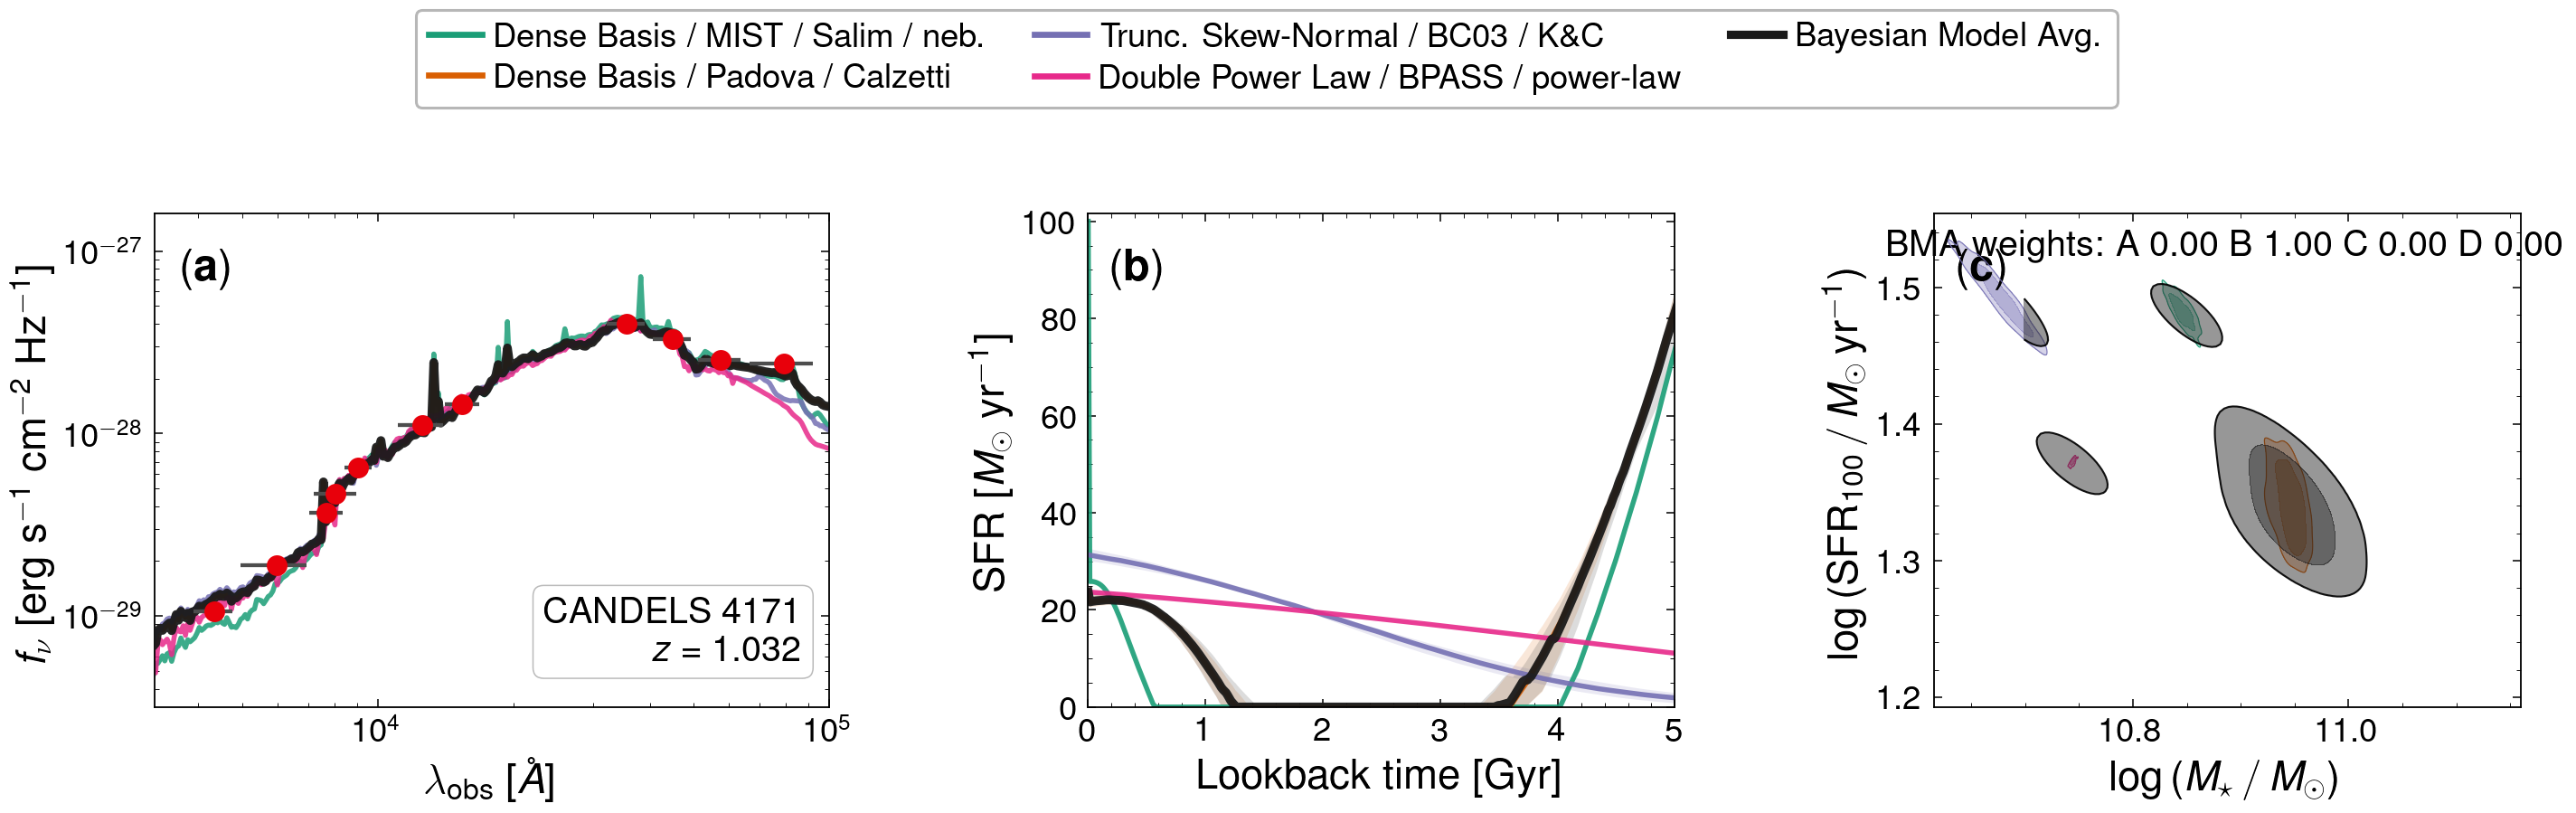

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [15]:
plot_galaxy(4171, presentation=True)

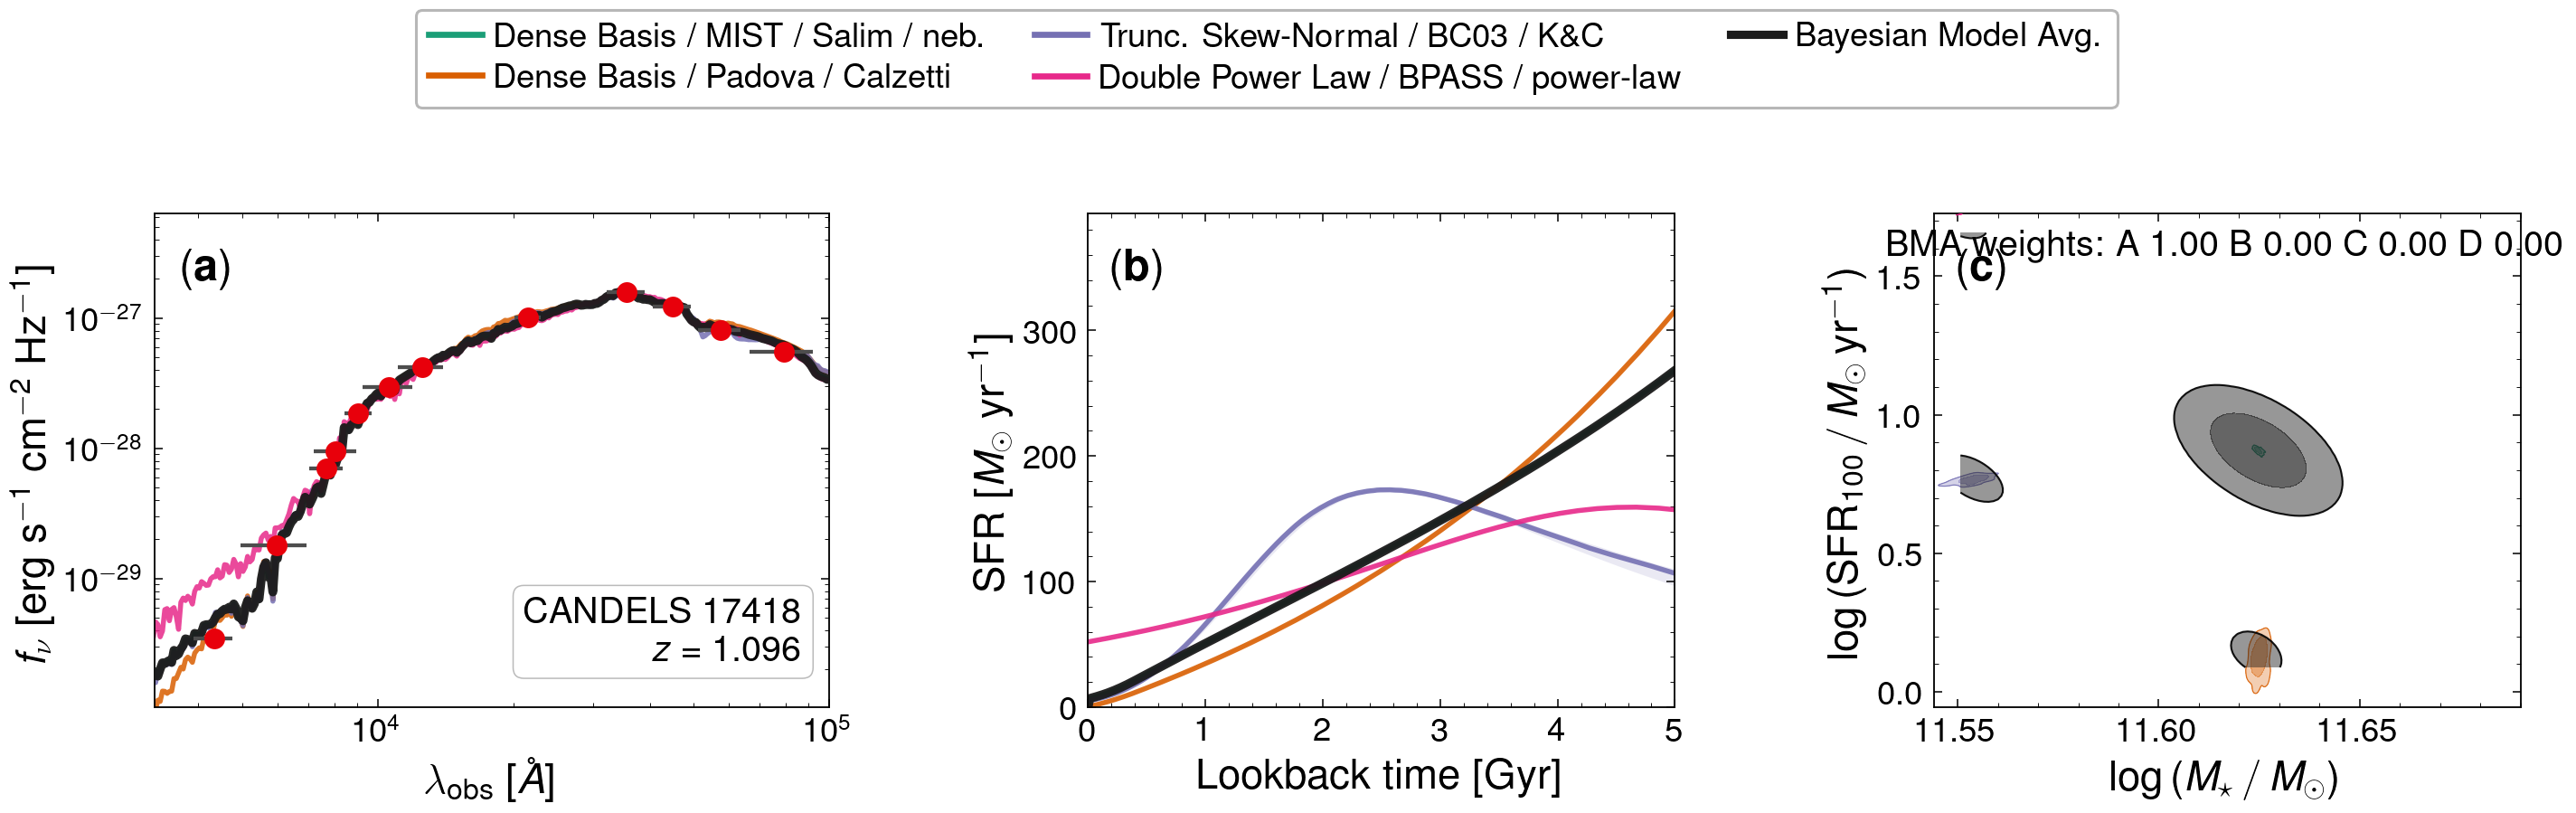

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [16]:
plot_galaxy(17418, presentation=True)

## 9. Takeaways

- **The evidence picks favourites.** The BMA weights are rarely uniform — one
  or two configurations usually dominate $\log Z$, and the average is pulled
  toward them while still retaining the others' spread.
- **The models genuinely disagree.** Panel (c) shows four tight but
  *separated* $M_\star$–SFR clusters: swapping SSP library, SFH family, or dust
  law moves the inferred stellar mass by a few tenths of a dex even at fixed
  photometry. That systematic spread is exactly what BMA exposes.
- **Same public surface throughout.** Every model came from
  `SEDModel.build(...)` with the nested-dict grammar; the only knob that
  changed for speed was `approx=WavePrecomp()`. Inference was the one-liner
  `Fitter(model, data, noise).run("nss", ...)`, whose `log_evidence` is what
  makes the averaging principled.